# Даалгавар

1. Кодыг гүйцээн ажиллуулах
2. Олон кернэл дээр ажилладаг болгох

3. Загварын суралцаж буй параметрүүдийн тоог гаргах
4. Сургалтын өгөгдлийг бүгдийг ашиглан сургалт хийх
5. Илүү гүн загварт сургалт хийх
6. Үр дүнг илүү сайн гаргах талаарх дүгнэлт хийх

In [10]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import cupy as np   

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

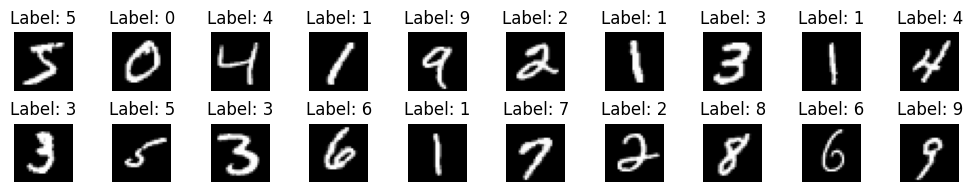

In [11]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

def show_samples(dataset, n= 20):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n//2, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')   
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)


In [12]:
class Linear_Layer:
    def __init__(self, in_dim, out_dim, alpha = 0.01, Theta = None, bias = None):
        self.alpha = alpha
        # He initialization for better gradient flow
        if Theta is None:
            self.Theta = np.random.randn(in_dim, out_dim) * np.sqrt(2.0 / in_dim)
        else:
            self.Theta = Theta
        if bias is None:
            self.bias = np.zeros(out_dim)
        else:
            self.bias = bias
    def forward_pass(self, X):
        self.X = X
        # self.z = None
        self.z = np.matmul(X, self.Theta) + self.bias
        return self.z
    def backprop(self, grad_previous):
        t= self.X.shape[0]
        # self.grad = None
        self.grad = np.matmul(self.X.T, grad_previous) / t
        # self.grad_bias = None
        self.grad_bias = np.sum(grad_previous, axis=0) / t
        self.grad_a = np.matmul(grad_previous, self.Theta.transpose())

        return self.grad_a
    def applying_sgd(self):
            self.Theta = self.Theta - (self.alpha*self.grad)
            self.bias = self.bias - (self.alpha*self.grad_bias)

In [13]:
class ConvLayer:
    def __init__(self, filter_dim=3, stride=1, pad=1, alpha=0.01, num_kernels=8, in_channels=None):
        """num_kernels: number of output channels (filters). in_channels: inferred from input if None."""
        self.filter_dim = filter_dim
        self.stride = stride
        self.num_kernels = num_kernels
        self.in_channels = in_channels  
        self.pad = pad
        self.alpha = alpha

    def _init_weights(self, in_ch):
        # He initialization for ReLU activation
        n = in_ch * self.filter_dim * self.filter_dim
        std = np.sqrt(2.0 / n)
        # filter shape: (num_kernels, in_channels, filter_dim, filter_dim)
        self.filter = np.random.randn(self.num_kernels, in_ch, self.filter_dim, self.filter_dim) * std
        self.bias = np.zeros(self.num_kernels)

    def _convolve_single(self, X, fil, dimen_x, dimen_y):
        """X: (in_ch, H, W), fil: (in_ch, f, f). Returns (dimen_x, dimen_y)."""
        z = np.zeros((dimen_x, dimen_y))
        in_ch, p, t = X.shape
        for i in range(dimen_x):
            for ii in range(dimen_y):
                x0 = i * self.stride
                y0 = ii * self.stride
                patch = X[:, x0:x0 + self.filter_dim, y0:y0 + self.filter_dim]
                z[i, ii] = np.sum(patch * fil)
        return z

    def forward_pass(self, X):
        # Normalize input: (N,H,W) -> (N,1,H,W); (N,C,H,W) stays
        if X.ndim == 3:
            X = X[:, np.newaxis, :, :]
        self.X = X
        N, in_ch, p, t = X.shape
        if not hasattr(self, 'filter') or self.filter is None:
            if self.in_channels is None:
                self.in_channels = in_ch
            self._init_weights(self.in_channels)

        dimen_x = int((p - self.filter_dim) / self.stride) + 1
        dimen_y = int((t - self.filter_dim) / self.stride) + 1
        self.z = np.zeros((N, self.num_kernels, dimen_x, dimen_y))

        for n in range(N):
            for k in range(self.num_kernels):
                self.z[n, k] = self._convolve_single(
                    self.X[n], self.filter[k], dimen_x, dimen_y
                ) + self.bias[k]
        return self.z

    def backprop(self, grad_z):
        N, K, out_h, out_w = grad_z.shape
        _, in_ch, in_h, in_w = self.X.shape
        F = self.filter_dim

        # Gradient w.r.t. input: dX[i,j] = sum over (oi,oj,fi,fj) where i=oi*stride+fi, j=oj*stride+fj
        self.grads = np.zeros_like(self.X)
        for n in range(N):
            for oi in range(out_h):
                for oj in range(out_w):
                    for fi in range(F):
                        for fj in range(F):
                            i, j = oi * self.stride + fi, oj * self.stride + fj
                            if 0 <= i < in_h and 0 <= j < in_w:
                                for c in range(in_ch):
                                    for k in range(K):
                                        self.grads[n, c, i, j] += grad_z[n, k, oi, oj] * self.filter[k, c, fi, fj]

        # Gradient w.r.t. filters
        self.grad_filter = np.zeros_like(self.filter)
        for k in range(K):
            for c in range(in_ch):
                for fi in range(F):
                    for fj in range(F):
                        self.grad_filter[k, c, fi, fj] = np.sum(
                            grad_z[:, k, :, :] * self.X[:, c, fi:fi+out_h*self.stride:self.stride, fj:fj+out_w*self.stride:self.stride]
                        )
        self.grad_filter = self.grad_filter / (N * out_h * out_w)
        self.grad_bias = np.sum(grad_z, axis=(0, 2, 3)) / (N * out_h * out_w)
        return self.grads

    def applying_sgd(self):
        self.filter = self.filter - self.alpha * self.grad_filter
        self.bias = self.bias - self.alpha * self.grad_bias

    def change_alpha(self):
        self.alpha = self.alpha / 10


In [14]:
class Pooling:
    def __init__(self, pool_dim=2, stride=2):
        self.pool_dim = pool_dim
        self.stride = stride

    def forward_pass(self, data):
        if data.ndim == 3:
            q, p, t = data.shape
            n_channels = 1
            data = data[:, np.newaxis, :, :]
        else:
            q, n_channels, p, t = data.shape
        z_x = int((p - self.pool_dim) / self.stride) + 1
        z_y = int((t - self.pool_dim) / self.stride) + 1
        after_pool = np.zeros((q, n_channels, z_x, z_y))
        for batch in range(q):
            for ch in range(n_channels):
                count = 0
                for i in range(0, p, self.stride):
                    for j in range(0, t, self.stride):
                        if (i + self.pool_dim <= p) and (j + self.pool_dim <= t):
                            temp = data[batch, ch, i:i + self.pool_dim, j:j + self.pool_dim]
                            after_pool[batch, ch, count // z_y, count % z_y] = np.max(temp)
                            count += 1
        return after_pool

    def backprop(self, pooled):
        if pooled.ndim == 3:
            a, b, c = pooled.shape
            pooled = pooled[:, np.newaxis, :, :]
        a, n_ch, b, c = pooled.shape
        cheated = np.zeros((a, n_ch, 2 * b, 2 * c))
        for batch in range(a):
            for ch in range(n_ch):
                count = 0
                for i in range(0, 2 * b, self.stride):
                    for j in range(0, 2 * c, self.stride):
                        cheated[batch, ch, i:i + self.stride, j:j + self.stride] = pooled[batch, ch, count // c, count % c]
                        count += 1
        return cheated

    def applying_sgd(self):
        pass


In [15]:
class softmax:
    def __init__(self):
        pass
    def expansion(self, t):
        (a,) = t.shape
        Y = np.zeros((a,10))
        for i in range(0,a):
            Y[i,t[i]] = 1
        return Y
    def forward_pass(self, z):
        self.z =  z

        # (p,t) = self.z.shape
        # self.a = np.zeros((p,t))
        # for i in range(0,p):
        #     for ii in range(0,t):
        #         self.a[i,ii] = None #

        z_shift = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shift)
        self.a = exp_z / np.sum(exp_z, axis=1, keepdims=True)
        return self.a
        
    def backprop(self, Y):
        y = self.expansion(Y)
        self.grad = (self.a - y)
        return self.grad
    def applying_sgd(self):
        pass

In [16]:
class relu:
    def __init__(self):
        pass
    def forward_pass(self, z):
        self.a = np.maximum(0, z)
        return self.a
    def derivative(self, a):
        return 1 if a > 0 else 0
    def backprop(self, grad_previous):
        self.grad = grad_previous * (self.a > 0)
        return self.grad
    def applying_sgd(self):
        pass


class padding():
    def __init__(self, pad=1):
        self.pad = pad
    def forward_pass(self, data):
        if data.ndim == 3:
            X = np.pad(data, ((0, 0), (self.pad, self.pad), (self.pad, self.pad)), 'constant', constant_values=0)
        else:
            X = np.pad(data, ((0, 0), (0, 0), (self.pad, self.pad), (self.pad, self.pad)), 'constant', constant_values=0)
        return X
    def backprop(self, y):
        if y.ndim == 3:
            return y[:, self.pad:(y.shape[1]-self.pad), self.pad:(y.shape[2]-self.pad)]
        return y[:, :, self.pad:(y.shape[2]-self.pad), self.pad:(y.shape[3]-self.pad)]
    def applying_sgd(self):
        pass


class reshaping:
    def __init__(self):
        pass
    def forward_pass(self, a):
        self.shape_a = a.shape
        self.final_a = a.reshape(self.shape_a[0], -1)
        return self.final_a
    def backprop(self, q):
        return q.reshape(self.shape_a)
    def applying_sgd(self):
        pass

class cross_entropy:
    def __init__(self):
        pass
    def expansion(self, t):
        (a,) = t.shape
        Y = np.zeros((a,10))
        for i in range(0,a):
            Y[i,t[i]] = 1
        return Y
    def loss(self, A, Y):
        eps = 1e-8
        A = np.clip(A, eps, 1 - eps)

        exp_Y = self.expansion(Y)
        (u,i) = A.shape
        loss_matrix = np.zeros((u,i))
        for j in range(u):
            for jj in range(i):
                if exp_Y[j,jj] == 0:
                    loss_matrix[j,jj] = np.log(1 - A[j,jj])
                else:
                    loss_matrix[j,jj] = np.log(A[j,jj])
        return ((-(loss_matrix.sum()))/u)

class accuracy:
    def __init__(self):
        pass
    def value(self, out, Y):
        self.out = np.argmax(out, axis=1)
        p = self.out.shape[0]
        total = 0
        for i in range(p):
            if Y[i]==self.out[i]:
                total += 1
        return total/p

class ConvNet:
    def __init__(self, Network):
        self.Network = Network
    def forward_pass(self, X):
        n = X
        for i in self.Network:
            n = i.forward_pass(n)
            # print(n.shape) #
        return n
    def backprop(self, Y):
        m = Y
        count = 1
        for i in (reversed(self.Network)):
            m = i.backprop(m)
    def applying_sgd(self):
        for i in self.Network:
            i.applying_sgd()

In [17]:

al = 0.3
stopper = 95

complete_NN = ConvNet([
    padding(),
    ConvLayer(num_kernels=8),
    Pooling(),
    relu(),

    padding(),
    ConvLayer(num_kernels=8, in_channels=8),
    Pooling(),
    relu(),

    ConvLayer(num_kernels=16, in_channels=8),
    relu(),

    reshaping(),
    Linear_Layer(16*5*5, 24, alpha=al),
    relu(),
    Linear_Layer(24, 10, alpha=al),
    softmax(),
])

CE = cross_entropy()
acc = accuracy()

In [18]:
# Training Configuration
epochs = 5
batch_size = 64

# Convert dataset to numpy arrays for training
def get_batches(dataset, batch_size, shuffle=True):
    """Generator to yield batches of data"""
    indices = list(range(len(dataset)))  # Use standard list instead of np.arange to avoid cupy issues
    if shuffle:
        np.random.shuffle(indices)
    
    for start_idx in range(0, len(dataset), batch_size):
        batch_indices = indices[start_idx:start_idx + batch_size]
        batch_images = []
        batch_labels = []
        
        for idx in batch_indices:
            idx = int(idx)  # Ensure idx is a Python int
            image, label = dataset[idx]
            # Convert to numpy array
            if isinstance(image, torch.Tensor):
                batch_images.append(image.numpy())
            else:
                batch_images.append(np.array(image))
            batch_labels.append(label)
        
        yield np.array(batch_images), np.array(batch_labels)

# Training loop
train_losses = []
train_accuracies = []

print("Starting training...")
for epoch in range(epochs):
    epoch_loss = 0
    epoch_correct = 0
    epoch_total = 0
    num_batches = 0
    
    # Training
    for batch_images, batch_labels in get_batches(train_dataset, batch_size):
        # Forward pass
        output = complete_NN.forward_pass(batch_images)
        
        # Calculate loss
        loss = CE.loss(output, batch_labels)
        epoch_loss += loss
        
        # Calculate accuracy
        batch_acc = acc.value(output, batch_labels)
        epoch_correct += batch_acc * len(batch_labels)
        epoch_total += len(batch_labels)
        
        # Backward pass
        complete_NN.backprop(batch_labels)
        
        # Update weights
        complete_NN.applying_sgd()
        
        num_batches += 1
        
        # Print progress every 100 batches
        if num_batches % 100 == 0:
            print(f"Epoch {epoch+1}, Batch {num_batches}, Loss: {loss:.4f}, Acc: {batch_acc:.4f}")
    
    # Calculate epoch metrics
    avg_loss = epoch_loss / num_batches
    avg_acc = epoch_correct / epoch_total
    
    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")

print("Training completed!")

Starting training...
Epoch 1, Batch 100, Loss: 3.2634, Acc: 0.1406
Epoch 1, Batch 200, Loss: 3.2363, Acc: 0.1875
Epoch 1, Batch 300, Loss: 3.2453, Acc: 0.1719


KeyboardInterrupt: 

In [ ]:
# Plot training loss
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluation on test set
print("Evaluating on test set...")
test_correct = 0
test_total = 0
all_predictions = []
all_true_labels = []

for batch_images, batch_labels in get_batches(test_dataset, batch_size=1000, shuffle=False):
    # Forward pass only (no gradient computation needed)
    output = complete_NN.forward_pass(batch_images)
    
    # Calculate accuracy
    batch_acc = acc.value(output, batch_labels)
    test_correct += batch_acc * len(batch_labels)
    test_total += len(batch_labels)
    
    # Store predictions for confusion matrix
    predictions = np.argmax(output, axis=1)
    all_predictions.extend(predictions)
    all_true_labels.extend(batch_labels)

test_accuracy = test_correct / test_total
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Calculate and print per-class accuracy
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

print("\nPer-class accuracy:")
for digit in range(10):
    mask = all_true_labels == digit
    if mask.sum() > 0:
        class_acc = (all_predictions[mask] == all_true_labels[mask]).mean()
        print(f"Digit {digit}: {class_acc:.4f}")

In [ ]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(all_true_labels, all_predictions))

In [ ]:
# Visualize some predictions
def show_predictions(dataset, num_samples=10):
    """Show sample predictions from the model"""
    plt.figure(figsize=(15, 3))
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        image, true_label = dataset[idx]
        
        # Get prediction
        image_np = image.numpy()[np.newaxis, :]  # Add batch dimension
        output = complete_NN.forward_pass(image_np)
        predicted_label = np.argmax(output[0])
        
        # Plot
        plt.subplot(2, num_samples//2, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        
        # Color code: green if correct, red if incorrect
        color = 'green' if predicted_label == true_label else 'red'
        plt.title(f'True: {true_label}\nPred: {predicted_label}', color=color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample Predictions:")
show_predictions(test_dataset)

In [ ]:

al = 0.3
stopper = 95

complete_NN = ConvNet([
    padding(),
    ConvLayer(num_kernels=8),
    Pooling(),
    relu(),

    padding(),
    ConvLayer(num_kernels=8, in_channels=8),
    Pooling(),
    relu(),

    ConvLayer(num_kernels=16, in_channels=8),
    relu(),

    reshaping(),
    Linear_Layer(16*5*5, 24, alpha=al),
    relu(),
    Linear_Layer(24, 10, alpha=al),
    softmax(),
])

CE = cross_entropy()
acc = accuracy()